# 🤖 Week 12 실습 — 트랜스포머 맛보기

**머신러닝 기초 및 실습 (학부) · Spring 2026**

ChatGPT의 뼈대인 **트랜스포머** 의 핵심 아이디어 **"Attention(주목)"** 을
**그림 위주** 로 가볍게 체험해 봅니다. 🎯

> 💡 **이번 실습의 목표:** 깊은 수학 X. **"트랜스포머가 대체 뭐 하는 거지?"** 의
> 직관을 그림과 간단한 코드로 잡는 것!

### 오늘의 여정 (약 25분)
| 파트 | 무엇을 해볼까요? | 강의 개념 |
|---|---|---|
| 1 | 같은 단어인데 뜻이 다르다? | 맥락의 중요성 |
| 2 | 단어를 평면 위의 '점'으로 보기 | 임베딩 |
| 3 | "그것은 누구?" — 가까운 친구 찾기 | Self-Attention |
| 4 | 순서 정보 살짝 맛보기 | Positional Encoding |
| 5 | 트랜스포머 블록 + 활용 | 블록 · GPT/BERT/ViT |

### 사용법
- **코드 한 줄 한 줄 다 이해 안 해도 OK!** 결과 그림을 보며 감을 잡으면 충분합니다.

> 🔑 한 줄 요약: **"기억하지 말고, 필요할 때 직접 찾아보자!"** — 이게 Attention 입니다.


## 0️⃣ 준비 — 도구 불러오기

NumPy(숫자 계산) + matplotlib(그림) 만 씁니다. 끝!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False

✅ 준비 완료!


## 1️⃣ 같은 단어인데 뜻이 다르다?

강의에서 본 예시 기억나죠?

- **배**가 고프다 🍙
- **배**를 타다 🚢
- **배**가 맛있다 🍐

같은 글자 **"배"** 인데 **주변 단어(맥락)** 가 뜻을 정합니다.
영어도 마찬가지로 **"bank"** 가 *river bank*(강가) ↔ *money bank*(은행) 가 됩니다.

> 그래서 트랜스포머는 단어 하나만 보지 않고
> **문장 안의 다른 단어들을 같이 살펴봅니다.**
> 이게 바로 **Attention** 이에요.


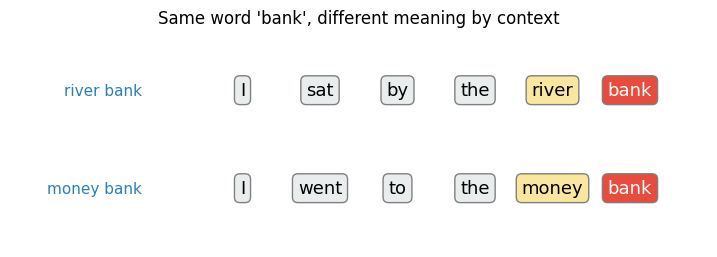

👉 옆에 'river'가 있냐 'money'가 있냐로 뜻이 갈립니다!


In [12]:
# 같은 단어 'bank'가 옆 단어에 따라 다른 뜻이 되는 모습 보기
sentences = [
    ("river bank", ["I", "sat", "by", "the", "river", "bank"]),
    ("money bank", ["I", "went", "to", "the", "money", "bank"]),
]

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis('off')
for row, (label, words) in enumerate(sentences):
    y = 1 - row
    for i, w in enumerate(words):
        is_bank = (w == 'bank')
        is_hint = (w in ('river', 'money'))
        color = '#E74C3C' if is_bank else ('#F9E79F' if is_hint else '#EAEDED')
        ax.text(i, y, w, ha='center', va='center', fontsize=13,
                color='white' if is_bank else 'black',
                bbox=dict(boxstyle='round', fc=color, ec='gray'))
    ax.text(-1.3, y, label, ha='right', va='center', fontsize=11, color='#2980B9')
ax.set_xlim(-3, 6); ax.set_ylim(-0.6, 1.6)
ax.set_title("Same word 'bank', different meaning by context", fontsize=12)
plt.show()
print("👉 옆에 'river'가 있냐 'money'가 있냐로 뜻이 갈립니다!")


## 2️⃣ 단어를 평면 위의 '점' 으로 보기 (임베딩)

컴퓨터는 글자를 모르고 **숫자** 만 압니다 (지난주 손글씨도 결국 숫자였죠).
그래서 각 단어를 **숫자(벡터)** 로 바꿉니다 — 이걸 **임베딩(embedding)** 이라 해요.

이번 실습에선 이해를 쉽게 하려고 단어를 **2차원 평면 위의 점** 으로 표현합니다.
**비슷한 뜻의 단어끼리는 가까이** 두기로 약속할게요.

> 강의의 예문 *"그 동물은 길을 건너지 않았다, 그것이 피곤했다"* 의 영어판으로 해봅니다:
>
> **"The animal didn't cross the street because it was tired"**


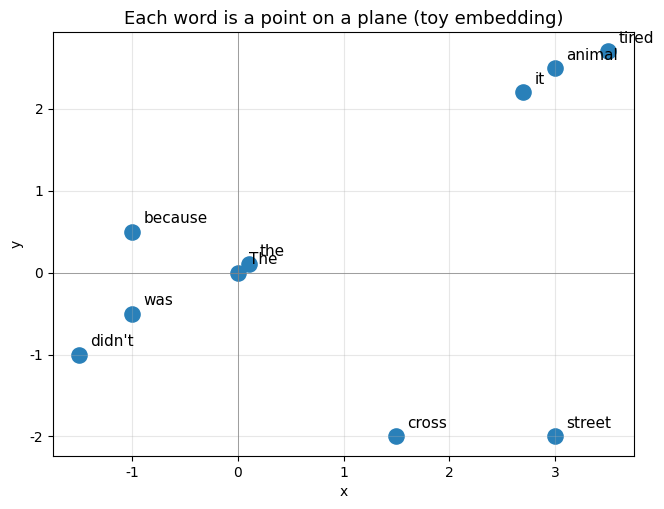

👀 'it' 점이 'animal', 'tired' 근처에 있는 게 보이나요?
   바로 이 '가까움'을 트랜스포머가 활용합니다.


In [13]:
# 문장의 단어들. 'it' 이 무엇을 가리키는지가 오늘의 미션!
tokens = ["The", "animal", "didn't", "cross", "the",
          "street", "because", "it", "was", "tired"]

# 각 단어를 2D 평면에 배치 (비슷한 뜻끼리 가까이)
#  - 'animal', 'it', 'tired' 는 오른쪽 위 (동물 관련)
#  - 'cross', 'street' 는 오른쪽 아래 (장소/동작)
#  - 'The', 'the', 'didn't', 'because', 'was' 는 중앙 근처 (기능어)
pos = np.array([
    [ 0.0,  0.0],  # The
    [ 3.0,  2.5],  # animal
    [-1.5, -1.0],  # didn't
    [ 1.5, -2.0],  # cross
    [ 0.1,  0.1],  # the
    [ 3.0, -2.0],  # street
    [-1.0,  0.5],  # because
    [ 2.7,  2.2],  # it       <- 'animal' 가까이! ('it' 이 가리키는 게 동물)
    [-1.0, -0.5],  # was
    [ 3.5,  2.7],  # tired
])

plt.figure(figsize=(7.5, 5.5))
plt.scatter(pos[:, 0], pos[:, 1], s=120, c='#2980B9')
for (x, y), w in zip(pos, tokens):
    plt.annotate(w, (x, y), textcoords='offset points', xytext=(8, 6),
                 fontsize=11)
plt.title("Each word is a point on a plane (toy embedding)", fontsize=13)
plt.xlabel("x"); plt.ylabel("y"); plt.grid(alpha=0.3)
plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
plt.show()

print("👀 'it' 점이 'animal', 'tired' 근처에 있는 게 보이나요?")
print("   바로 이 '가까움'을 트랜스포머가 활용합니다.")


## 3️⃣ Self-Attention — "그것(it)은 누구?" 가까운 친구 찾기 ⭐

이번 파트가 **트랜스포머의 심장** 입니다. 그런데 어렵지 않아요!

> **아이디어:** 각 단어가 *"나랑 가장 관련 깊은 단어가 누구지?"* 를 묻고,
> **가까운 단어일수록 더 많이 참고** 합니다.

순서는 단 **3단계**:
1. 단어 쌍마다 **"얼마나 가까운지"** 점수를 매긴다 (= 거리가 짧을수록 높은 점수)
2. **softmax** 로 점수를 **확률(합=1)** 로 바꾼다  *(지난주 손글씨에서 본 그 softmax!)*
3. 그 확률이 **"각 단어에 얼마나 주목할지"** = **Attention** 입니다 🎯

(실제 트랜스포머 공식은 $\text{softmax}(QK^\top/\sqrt{d})V$ 인데,
지금은 "가까울수록 주목" 으로 단순화해 직관만 잡습니다.)


In [14]:
# 1) 모든 단어 쌍의 거리 계산
diff = pos[:, None, :] - pos[None, :, :]     # 모든 쌍의 (dx, dy)
dist = np.sqrt((diff ** 2).sum(-1))          # 거리 행렬

# 점수 = '가까울수록 높게' → 거리에 마이너스
scores = -dist
# 자기 자신은 빼고 다른 단어 중에서만 찾기로 함 (그래야 'it -> animal'이 보임)
np.fill_diagonal(scores, -np.inf)

# 2) softmax 로 점수를 확률로 (각 행의 합 = 1)
def softmax(z):
    z = z - np.max(z, axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

attention = softmax(scores)

# 3) 'it' 행에서 누구를 가장 많이 보는지 확인
it = tokens.index("it")
ranking = np.argsort(-attention[it])
print("[ 'it' 가 주목하는 단어 TOP 4 ]")
for r in ranking[:4]:
    print(f"   {tokens[r]:<8}  {attention[it, r]*100:5.1f}%")
print(f"\n→ 'it' 는 '{tokens[ranking[0]]}' 를 가장 강하게 주목합니다!")
print("  (강의의 '그것이 → 동물은' 과 똑같죠!)")


[ 'it' 가 주목하는 단어 TOP 4 ]
   animal     55.9%
   tired      33.3%
   the         3.0%
   The         2.6%

→ 'it' 는 'animal' 를 가장 강하게 주목합니다!
  (강의의 '그것이 → 동물은' 과 똑같죠!)


### 🔥 어텐션 히트맵 — 한눈에 보기

행 = "질문하는 단어", 열 = "주목받는 단어".
**색이 진할(밝을)수록 더 많이 주목** 한다는 뜻입니다.

특히 **`it` 행** 을 따라가 보세요 — `animal` 칸이 가장 밝게 빛납니다 ✨


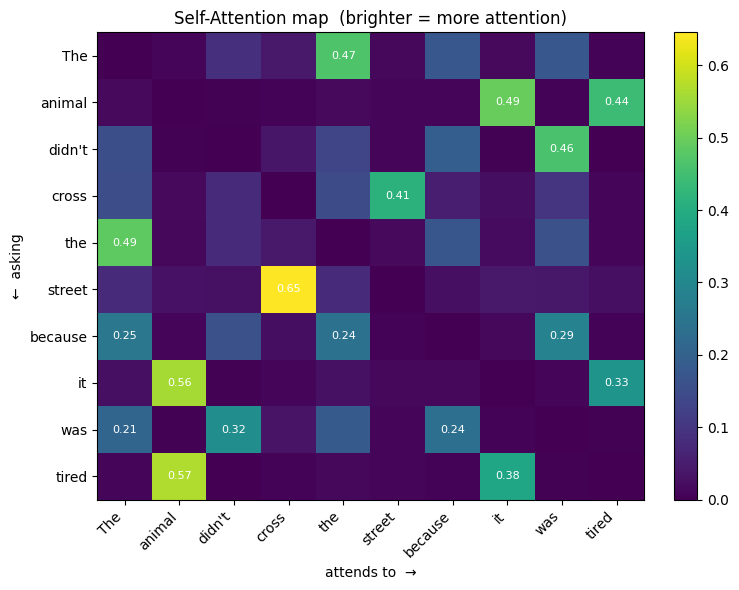

거리가 멀어도 직접 연결! (RNN처럼 멀어서 잊는 일이 없어요)


In [15]:
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(attention, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
ax.set_xlabel("attends to  →"); ax.set_ylabel("←  asking")
ax.set_title("Self-Attention map  (brighter = more attention)", fontsize=12)
# 0.2 넘는 값은 숫자로도 표시
for r in range(len(tokens)):
    for c in range(len(tokens)):
        if attention[r, c] > 0.20:
            ax.text(c, r, f"{attention[r,c]:.2f}", ha='center', va='center',
                    color='white', fontsize=8)
plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

print("거리가 멀어도 직접 연결! (RNN처럼 멀어서 잊는 일이 없어요)")


## 4️⃣ 순서 정보 — Positional Encoding 살짝

Attention 만 쓰면 단어들을 **'집합'처럼** 봐서 **순서를 모릅니다.**

- *"나는 너를 좋아해"* 와 *"너를 나는 좋아해"* 를 구별 못 함 😱

그래서 각 위치마다 **고유한 무늬의 신호(파동)** 를 만들어 단어 벡터에 더해줍니다.
이걸 **Positional Encoding** 이라 해요. 어떻게 생겼는지 그림만 한 번 보고 갈게요.


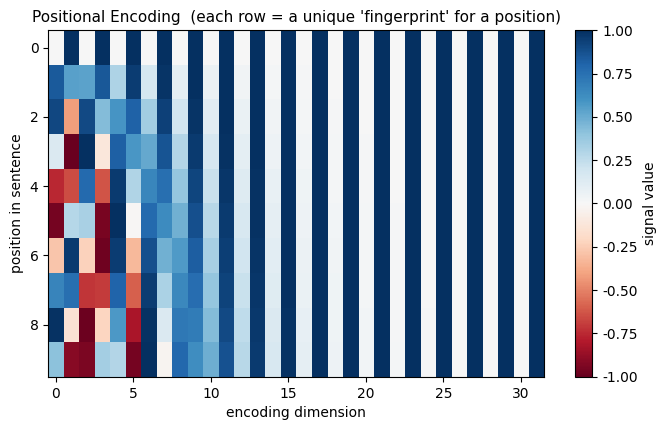

위치마다 줄무늬가 다르죠? 이걸 단어 벡터에 더해주면
→ 모델이 '몇 번째 단어인지'까지 알 수 있습니다.


In [16]:
# 위치 인코딩 표 만들기 (sin/cos 파동 — 식은 외울 필요 X, 그림만 보세요)
length, d = 10, 32
i = np.arange(d)[None, :]
p = np.arange(length)[:, None]
angle = p / np.power(10000, (2 * (i // 2)) / d)
PE = np.where(i % 2 == 0, np.sin(angle), np.cos(angle))

plt.figure(figsize=(8, 4.5))
plt.imshow(PE, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='signal value')
plt.xlabel("encoding dimension")
plt.ylabel("position in sentence")
plt.title("Positional Encoding  (each row = a unique 'fingerprint' for a position)",
          fontsize=11)
plt.show()

print("위치마다 줄무늬가 다르죠? 이걸 단어 벡터에 더해주면")
print("→ 모델이 '몇 번째 단어인지'까지 알 수 있습니다.")


## 5️⃣ 트랜스포머 블록 + 활용 한 눈에 🧱

지금까지 본 **Self-Attention** 에 **작은 신경망(지난주 배운 MLP)** 을 붙이고,
**Residual(입력 더하기) + Norm(정규화)** 으로 학습을 안정화한 것이
**트랜스포머 블록 1개** 입니다. 이걸 **N개 쌓으면** GPT/BERT가 됩니다.

```
        ┌──────────────────────────────────┐
        │  Input  (단어 임베딩 + 위치 정보)   │
        └──────────────────────────────────┘
                       │
                       ▼
        ┌──────────────────────────────────┐
        │  ① Self-Attention                │   ← 단어들이 서로 본다 (방금 우리가 함!)
        └──────────────────────────────────┘
                       │
                       ▼
        ┌──────────────────────────────────┐
        │  ② Add & Norm                    │
        └──────────────────────────────────┘
                       │
                       ▼
        ┌──────────────────────────────────┐
        │  ③ Feed-Forward (작은 MLP)        │   ← 지난주 배운 그 신경망!
        └──────────────────────────────────┘
                       │
                       ▼
        ┌──────────────────────────────────┐
        │  ④ Add & Norm                    │
        └──────────────────────────────────┘
                       │
                       ▼
                   (×  N 번 반복)
```

### 트랜스포머의 3가지 얼굴

| 모델 | 어디 쓰나? | 핵심 |
|---|---|---|
| **GPT** (ChatGPT) ✍️ | 글쓰기·대화·코딩 | 디코더 사용 · **다음 단어 맞히기** 로 학습 |
| **BERT** 🔎 | 검색·감성분석·이해 | 인코더 사용 · **빈칸 맞히기** 로 학습 |
| **ViT** 🖼️ | 이미지 처리 | 이미지를 **작은 조각(patch)** 으로 잘라 '단어처럼' 다룸 |

> 💡 *Multi-Head Attention?* 우리가 한 어텐션을 **여러 번 동시에** 돌리면,
> 각각 다른 관계(문법·의미·맥락 등)에 주목하는 **여러 시선** 이 생깁니다.
> 강의에서 본 "문법 head / 의미 head / 맥락 head" 가 그것!


### 🖼️ 보너스 — 이미지도 토큰이 된다 (ViT 맛보기)

지난주에 본 **손글씨 숫자** 이미지를 **4조각(patch)** 으로 잘라
**'단어처럼'** 트랜스포머에 넣을 수 있다는 게 ViT의 아이디어예요.


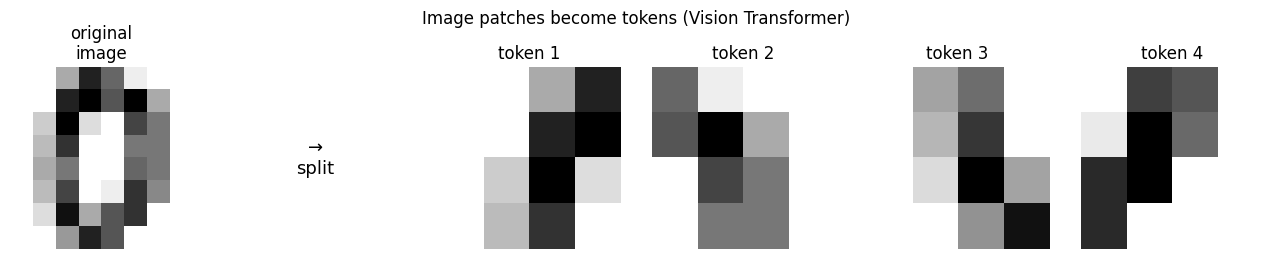

이미지가 4개의 '토큰(조각)' 으로 변신!
이 토큰들을 단어처럼 트랜스포머에 넣으면 → 그림도 이해/생성 가능!


In [17]:
from sklearn.datasets import load_digits

img = load_digits().images[0]      # 8x8 손글씨 (지난주 그 데이터!)
P = 4                              # 패치 크기 4x4 → 4조각
patches = [img[r:r+P, c:c+P] for r in (0, 4) for c in (0, 4)]

fig, axes = plt.subplots(1, 6, figsize=(13, 2.6))
axes[0].imshow(img, cmap='gray_r'); axes[0].set_title("original\nimage")
axes[0].axis('off')
axes[1].axis('off'); axes[1].text(0.5, 0.5, "→\nsplit", ha='center',
                                  va='center', fontsize=13)
for k, (ax, p_img) in enumerate(zip(axes[2:], patches)):
    ax.imshow(p_img, cmap='gray_r'); ax.set_title(f"token {k+1}")
    ax.axis('off')
plt.suptitle("Image patches become tokens (Vision Transformer)", fontsize=12)
plt.tight_layout(); plt.show()

print("이미지가 4개의 '토큰(조각)' 으로 변신!")
print("이 토큰들을 단어처럼 트랜스포머에 넣으면 → 그림도 이해/생성 가능!")


## 🎓 정리 — 오늘 우리가 본 것

| 실습 | 확인한 강의 개념 |
|---|---|
| 1️⃣ 'bank' 의 두 얼굴 | 단어 뜻은 **맥락** 이 정한다 |
| 2️⃣ 단어 = 평면 위의 점 | **임베딩** (단어→숫자) |
| 3️⃣ 'it → animal' 히트맵 | **Self-Attention** = 가까운 친구 찾기 + softmax |
| 4️⃣ Positional Encoding | **순서 정보** 를 신호로 더해주기 |
| 5️⃣ 블록 + 패치 토큰 | **블록 구조** · GPT/BERT/ViT |

**한 줄 요약:** 트랜스포머 = **"문장의 모든 단어가 서로를 보며 누구를 참고할지 정한다"**.
이걸 위해 (a) 단어를 숫자로 만들고, (b) 위치 정보를 더하고,
(c) Self-Attention 으로 서로 주목하고, (d) 작은 MLP로 가공하고, (e) 여러 블록 쌓는다.

### 🧪 도전 과제 (가볍게!)
1. **2️⃣** 에서 `it` 의 좌표를 `[2.7, 2.2]` 대신 **`[3.0, -2.0]`** (= `street` 위치) 로 바꾸면
   히트맵에서 `it` 는 누구를 가장 많이 볼까요?
2. **3️⃣** 의 `np.fill_diagonal(scores, -np.inf)` 줄을 지우면 (자기 자신도 보게 하면) 어떻게 될까요?
3. **5️⃣** 의 패치 크기 `P = 4` 를 `2` 로 바꾸면 토큰이 몇 개가 될까요?

**한 학기 수고하셨습니다!** 🎉 (Week 11 뉴럴넷 → Week 12 트랜스포머까지 완주!)
